In [8]:
import devsim as ds
import python_packages.simple_physics as sp
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

ds.set_parameter(name="debug_level", value="verbose")

In [9]:
# Device sizing
CHANNEL_LENGTH = 50e-7 #cm
DIFF_LENGTH = 50e-7
MIDPOINT = (DIFF_LENGTH + CHANNEL_LENGTH)/2
OXIDE_THICKNESS = 2e-7
BULK_THICKNESS = 7e-6
JUNCTION_DEPTH = 2e-6

# Doping
BULK_DOPING = 1e18 # cm^-3
SOURCE_DOPING = 2e20
HALO_DOPING = 5e17 # cm,^-3 --> Halo region
DRAIN_DOPING = 1e17 #cm^-3 --> LDD Gradient

# Device and region definitions
DEVICE = "mosfet"
REG_SI = "silicon"
REG_OX = "oxide"
INTERFACE = "si_ox_interface"

In [10]:
def createMosfetMesh(device):
    try:
        ds.delete_device(device=DEVICE)
        ds.delete_mesh(mesh=DEVICE)
    except:
        "We don't need to do anything here since the device doesn't exist"
        
    ds.create_2d_mesh(mesh=device)

    oxide_start=OXIDE_THICKNESS
    bulk_start=0.0
    bulk_end=-BULK_THICKNESS
    ds.add_2d_mesh_line(mesh=device, dir="y", pos=oxide_start+1e-7, ps=0.5e-7)
    ds.add_2d_mesh_line(mesh=device, dir="y", pos=oxide_start, ps=0.5e-7)
    ds.add_2d_mesh_line(mesh=device, dir="y", pos=bulk_start, ps=0.2e-7)
    ds.add_2d_mesh_line(mesh=device, dir="y", pos=bulk_end, ps=1e-6)
    ds.add_2d_mesh_line(mesh=device, dir="y", pos=bulk_end - 2e-6, ps=1e-6)

    dev_start=0.0
    gate_start=DIFF_LENGTH
    gate_end=CHANNEL_LENGTH+DIFF_LENGTH
    dev_end=2*DIFF_LENGTH + CHANNEL_LENGTH
    ds.add_2d_mesh_line(mesh=device, dir="x", pos=dev_start, ps=1e-7)
    ds.add_2d_mesh_line(mesh=device, dir="x", pos=gate_start, ps=0.5e-6)
    ds.add_2d_mesh_line(mesh=device, dir="x", pos=gate_end, ps=0.5e-6)
    ds.add_2d_mesh_line(mesh=device, dir="x", pos=dev_end, ps=1e-7)

    # Create regions.  We must create several 'empty' regions, because DEVSIM only allows contacts
    # between regions
    ds.add_2d_region(
        mesh=device,
        region="top_space",
        material="Air",
        xl=dev_start,
        xh=dev_end,
        yl=oxide_start+1e-7,
        yh=oxide_start
    )
    ds.add_2d_region(
        mesh=device,
        region=REG_SI,
        material="Silicon",
        xl=dev_start,
        xh=dev_end,
        yl=bulk_start,
        yh=bulk_end
    )
    ds.add_2d_region(
        mesh=device,
        region=REG_OX,
        material="SiliconOxide",
        xl=gate_start,
        xh=gate_end,
        yl=oxide_start,
        yh=bulk_start
    )
    ds.add_2d_region(
        mesh=device,
        region="left_space",
        material="Air",
        xl=dev_start,
        xh=gate_start,
        yl=oxide_start,
        yh=bulk_start
    )
    ds.add_2d_region(
        mesh=device,
        region="right_space",
        material="Air",
        xl=gate_end,
        xh=dev_end,
        yl=oxide_start,
        yh=bulk_start
    )
    ds.add_2d_region(
        mesh=device,
        region="bot_space",
        material="Air",
        xl=dev_start,
        xh=dev_end,
        yl=bulk_end,
        yh=bulk_end - 2e-6
    )
    # Create the Si-SiO2 Interface
    ds.add_2d_interface(
        mesh=device,
        name=INTERFACE,
        region0=REG_SI,
        region1=REG_OX,
        xl=gate_start,
        xh=gate_end,
        yl=bulk_start,
        yh=bulk_start
    )
    # Add contacts for gate, source, drain, and body
    ds.add_2d_contact(
        mesh=device,
        name="gate",
        region=REG_OX,
        material="metal",
        yl=oxide_start,
        yh=oxide_start,
        xl=gate_start,
        xh=gate_end
    )
    ds.add_2d_contact(
        mesh=device,
        name="source",
        region=REG_SI,
        material="metal",
        yl=bulk_start,
        yh=bulk_start,
        xl=dev_start,
        xh=gate_start - 1e-7
    )

    #Adding the halo regions for both source and drain
    ds.add_2d_contact(
        mesh=device,
        name="halo_source",
        region=REG_SI,
        material="metal",
        yl=bulk_start,
        yh=bulk_start,
        xl=gate_start - 1e-7,
        xh=gate_start - 1e-9
    )
    ds.add_2d_contact(
        mesh=device,
        name="halo_drain",
        region=REG_SI,
        material="metal",
        yl=bulk_start,
        yh=bulk_start,
        xl=gate_start + 1e-9,
        xh=gate_start + 1e-7
    )
    ds.add_2d_contact(
        mesh=device,
        name="drain",
        region=REG_SI,
        material="metal",
        yl=bulk_start,
        yh=bulk_start,
        xl=gate_end + 1e-7,
        xh=dev_end
    )
    ds.add_2d_contact(
        mesh=device,
        name="body",
        region=REG_SI,
        material="metal",
        yl=bulk_end,
        yh=bulk_end,
        xl=dev_start,
        xh=dev_end
    )

    #print(ds.get_parameter(mesh=device, name="metal"))

    ds.finalize_mesh(mesh=device)
    ds.create_device(mesh=device, device=device)

In [11]:
def create_potential_equations_with_bias(body_bias=0.0, source_bias=0.0, gate_bias=0.0, drain_bias=0.0, halo_doping=True):
    sp.SetSiliconParameters(DEVICE, REG_SI, 300)
    sp.SetOxideParameters(DEVICE, REG_OX, 300)
    # p-type doping
    ds.node_model(device=DEVICE, region=REG_SI, name="Halo_Source_Doping", equation=f"{HALO_DOPING} * ((x > {DIFF_LENGTH}) * (x < ({MIDPOINT})) * (y >= {-JUNCTION_DEPTH}))")
    ds.node_model(device=DEVICE, region=REG_SI, name="Halo_Drain_Doping", equation=f"{HALO_DOPING} * ((x > ({MIDPOINT})) * (x < {DIFF_LENGTH + CHANNEL_LENGTH}) * (y >= {-JUNCTION_DEPTH}))")
    #Checking halo doping is required or not
    if halo_doping:
        ds.node_model(device=DEVICE, region=REG_SI, name="Acceptors", equation=f"{BULK_DOPING} + Halo_Source_Doping + Halo_Drain_Doping")
    else:
        ds.node_model(device=DEVICE, region=REG_SI, name="Acceptors", equation=f"{BULK_DOPING}")
    # n-type doping
    ds.node_model(device=DEVICE, region=REG_SI, name="Source_Doping", equation=f"{SOURCE_DOPING} * (x <= {DIFF_LENGTH})* (y >= {-JUNCTION_DEPTH})")
    ds.node_model(device=DEVICE, region=REG_SI, name="Drain_Doping", equation=f"{DRAIN_DOPING} * (x >= {CHANNEL_LENGTH + DIFF_LENGTH}) * (y >= {-JUNCTION_DEPTH})")
    ds.node_model(device=DEVICE, region=REG_SI, name="Donors", equation="Source_Doping + Drain_Doping")

    # Net Doping
    ds.node_model(device=DEVICE, region=REG_SI, name="NetDoping", equation="Donors - Acceptors")
    # Create potential solutions
    sp.CreateSolution(DEVICE, REG_SI, "Potential")
    sp.CreateSolution(DEVICE, REG_OX, "Potential")

    sp.CreateSiliconPotentialOnly(DEVICE, REG_SI)
    sp.CreateOxidePotentialOnly(DEVICE, REG_OX)

    sp.CreateSiliconOxideInterface(DEVICE, INTERFACE)

    # Add biases to each contact.
    ds.set_parameter(device=DEVICE, name="source_bias", value=source_bias)
    ds.set_parameter(device=DEVICE, name="gate_bias", value=gate_bias)
    ds.set_parameter(device=DEVICE, name="drain_bias", value=drain_bias)
    ds.set_parameter(device=DEVICE, name="body_bias", value=body_bias)

    # Create solutions for contacts at gate, source, body, and drain
    sp.CreateSiliconPotentialOnlyContact(DEVICE, REG_SI, "source")
    sp.CreateSiliconPotentialOnlyContact(DEVICE, REG_SI, "body")
    sp.CreateSiliconPotentialOnlyContact(DEVICE, REG_SI, "drain")
    sp.CreateOxideContact(DEVICE, REG_OX, "gate")

    # Set workfunction for p-type polysilicon
    ds.set_parameter(device=DEVICE, region=REG_OX, name="WorkFunction", value=5.17)

def create_drift_diffusion_equations():
    # Drift-Diffusion
    sp.CreateSolution(DEVICE, REG_SI, "Electrons")
    sp.CreateSolution(DEVICE, REG_SI, "Holes")

    ds.set_node_values(device=DEVICE, region=REG_SI,
    name="Electrons", init_from="IntrinsicElectrons")
    ds.set_node_values(device=DEVICE, region=REG_SI,
    name="Holes", init_from="IntrinsicHoles")

    sp.CreateSiliconDriftDiffusion(DEVICE, REG_SI, "mu_n", "mu_p")

    sp.CreateSiliconDriftDiffusionAtContact(DEVICE, REG_SI, "source")
    sp.CreateSiliconDriftDiffusionAtContact(DEVICE, REG_SI, "drain")
    sp.CreateSiliconDriftDiffusionAtContact(DEVICE, REG_SI, "body")
    sp.CreateSiliconOxideInterface(DEVICE, INTERFACE) # Just in case, doesn't hurt to be careful

In [12]:
def calculate(): 
    #Solving for drift diffusion
    createMosfetMesh(DEVICE)
    create_potential_equations_with_bias(body_bias=0.0, source_bias=0.0, gate_bias=1.0, drain_bias=0.0, halo_doping=False)
    ds.solve(type="dc", absolute_error=1.0, relative_error=1e-10, maximum_iterations=30)

    create_drift_diffusion_equations()
    ds.solve(type="dc", absolute_error=1e10, relative_error=1e-7, maximum_iterations=30)

    for vds in [0.1, 0.2, 0.5, 1.0]:
        ds.set_parameter(device=DEVICE, name="drain_bias", value=vds)
        ds.solve(type="dc", absolute_error=1e10, relative_error=1e-7, maximum_iterations=30)

    #Now solving for Ex, n, and hot-carrier injection
    ds.edge_model(device=DEVICE, region=REG_SI, name="Efield_x", equation="-(Potential@n1 - Potential@n0) / EdgeLength")
    ds.edge_from_node_model(device=DEVICE, region=REG_SI, node_model="x")
    ds.edge_from_node_model(device=DEVICE, region=REG_SI, node_model="y")

    #Extracting data for plot
    x_vals  = np.array(ds.get_edge_model_values(device=DEVICE, region=REG_SI, name="x@n0"))
    y_vals  = np.array(ds.get_edge_model_values(device=DEVICE, region=REG_SI, name="y@n0"))

    Ex_surf = np.array(ds.get_edge_model_values(device=DEVICE, region=REG_SI, name="Efield_x"))

    #Adding a mask to robustify the data
    surface_tolerance = 1e-9
    mask = np.abs(y_vals) < surface_tolerance

    #Applying the mask
    x_surf = x_vals[mask]
    Ex_surf = Ex_surf[mask]

    #Sorting the data
    sort_id = np.argsort(x_surf)
    x_surf = x_surf[sort_id]
    Ex_surf = Ex_surf[sort_id]

    return x_surf, Ex_surf

Creating Region bot_space
Creating Region silicon
Creating Region left_space
Creating Region top_space
Creating Region oxide
Creating Region right_space
Contact: body region silicon ni: 0 ci: 2 (0, -7e-06, 0)
Contact: source region silicon ni: 54 ci: 29 (0, 0, 0)
Contact: body region silicon ni: 2 ci: 41 (1e-07, -7e-06, 0)
Contact: source region silicon ni: 55 ci: 68 (1e-07, 0, 0)
Contact: body region silicon ni: 56 ci: 80 (2.08889e-07, -7e-06, 0)
Contact: source region silicon ni: 83 ci: 107 (2.08889e-07, 0, 0)
Contact: body region silicon ni: 84 ci: 119 (3.27457e-07, -7e-06, 0)
Contact: source region silicon ni: 111 ci: 146 (3.27457e-07, 0, 0)
Contact: body region silicon ni: 112 ci: 158 (4.56564e-07, -7e-06, 0)
Contact: source region silicon ni: 139 ci: 185 (4.56564e-07, 0, 0)
Contact: body region silicon ni: 140 ci: 197 (5.97148e-07, -7e-06, 0)
Contact: source region silicon ni: 167 ci: 224 (5.97148e-07, 0, 0)
Contact: body region silicon ni: 168 ci: 236 (7.50227e-07, -7e-06, 0)
Co

/tmp/ipykernel_633207/3262660049.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


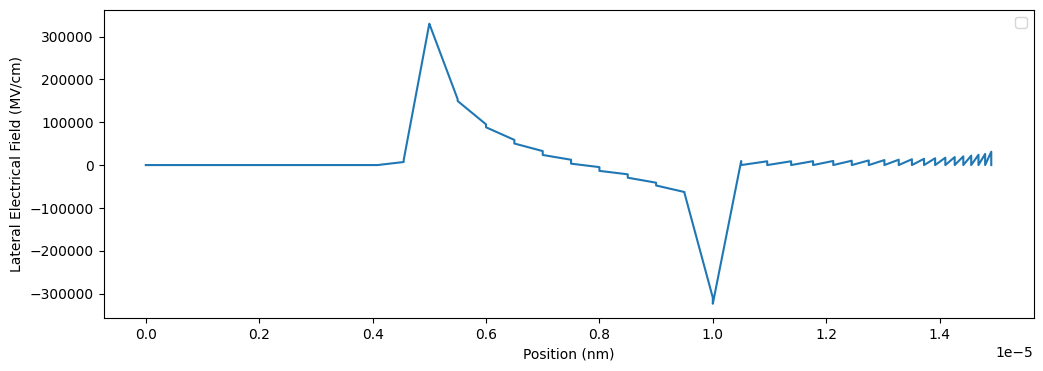

In [13]:
plt.figure(figsize=(12,4))
x, Ex = calculate()

plt.plot(x, (Ex))
plt.xlabel("Position (nm)")
plt.ylabel("Lateral Electrical Field (MV/cm)")
plt.legend()

Creating Region bot_space
Creating Region silicon
Creating Region left_space
Creating Region top_space
Creating Region oxide
Creating Region right_space
Contact: body region silicon ni: 0 ci: 2 (0, -7e-06, 0)
Contact: source region silicon ni: 54 ci: 29 (0, 0, 0)
Contact: body region silicon ni: 2 ci: 41 (1e-07, -7e-06, 0)
Contact: source region silicon ni: 55 ci: 68 (1e-07, 0, 0)
Contact: body region silicon ni: 56 ci: 80 (2.08889e-07, -7e-06, 0)
Contact: source region silicon ni: 83 ci: 107 (2.08889e-07, 0, 0)
Contact: body region silicon ni: 84 ci: 119 (3.27457e-07, -7e-06, 0)
Contact: source region silicon ni: 111 ci: 146 (3.27457e-07, 0, 0)
Contact: body region silicon ni: 112 ci: 158 (4.56564e-07, -7e-06, 0)
Contact: source region silicon ni: 139 ci: 185 (4.56564e-07, 0, 0)
Contact: body region silicon ni: 140 ci: 197 (5.97148e-07, -7e-06, 0)
Contact: source region silicon ni: 167 ci: 224 (5.97148e-07, 0, 0)
Contact: body region silicon ni: 168 ci: 236 (7.50227e-07, -7e-06, 0)
Co

Text(0.5, 1.0, '$V_{GS} = 1.0$')

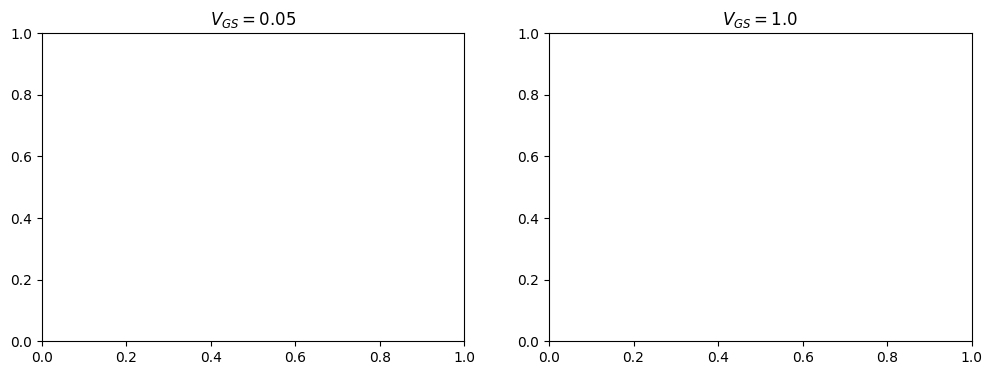

In [ ]:
from math import log

def plot_potential_x():
    Nc = 3.2e19
    Nv = 2.03e19
    ni = 9.963e9
    q = 1.6e-19
    k = 1.3806503e-23
    Vt = k * 300 / q

    x_si = np.array(ds.get_node_model_values(device=DEVICE, region=REG_SI, name="x"))
    y_si = np.array(ds.get_node_model_values(device=DEVICE, region=REG_SI, name="y"))
    electrons = np.array(ds.get_node_model_values(device=DEVICE, region=REG_SI, name="Electrons"))
    potential_si= np.array(ds.get_node_model_values(device=DEVICE, region=REG_SI, name="Potential"))

    max_y = np.max(y_si[y_si != np.max(y_si)])
    x = x_si[y_si == max_y] / 1e-4
    n = electrons[y_si == max_y]
    psi = potential_si[y_si == max_y]

    # Calculate the offsets for the valence band and conduction band wrt Ei (-psi * q)
    chi_c = Vt * log(Nc / ni)
    chi_v = Vt * log(Nv / ni)
    E_f_n = -psi + Vt * np.log(n/ni)

    plt.plot(x, -psi + chi_c, label="$E_C$")
    plt.plot(x, E_f_n, color="green", label="$E_f$", linestyle=":")
    plt.plot(x, -psi, label="$E_i$", linestyle=":", color="gray")
    plt.plot(x, -psi - chi_v, label="$E_V$")
    plt.xlabel("$x$ ($\mu m$)")
    plt.ylabel("Potential (eV)")
    plt.legend()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
createMosfetMesh(DEVICE)
create_potential_equations_with_bias(body_bias=0.0, source_bias=0.0, gate_bias=0.0, drain_bias=0.05)
ds.solve(type="dc", absolute_error=1e10, relative_error=1e-10, maximum_iterations=30)
create_drift_diffusion_equations()
ds.solve(type="dc", absolute_error=1e10, relative_error=1e-3, maximum_iterations=100)
plot_potential_x()
plt.title("$V_{GS} = 0.05$")

plt.subplot(1,2,2)
createMosfetMesh(DEVICE)
create_potential_equations_with_bias(body_bias=0.0, source_bias=0.0, gate_bias=0.0, drain_bias=1.0)
ds.solve(type="dc", absolute_error=1e10, relative_error=1e-10, maximum_iterations=30)
create_drift_diffusion_equations()
ds.solve(type="dc", absolute_error=1e10, relative_error=1e-3, maximum_iterations=100)
plot_potential_x()
plt.title("$V_{GS} = 1.0$")